# H-008 · Half-life gate (trad-z)

Arms: `off` | primary band `[5, 60]` | alternate `[5, 30]`. Not a grid.

Type `HL_GATE_STAR` as `"off"`, `"5_60"`, or `"5_30"`.


## 0. Imports & Config


In [1]:
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd

ROOT = os.path.abspath(os.getcwd())
while not os.path.isdir(os.path.join(ROOT, "01_data", "ingestion")):
    parent = os.path.dirname(ROOT)
    if parent == ROOT:
        break
    ROOT = parent
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from backtest.s2_coint.report import (
    arm_selection_table,
    fold_table,
    fold_val_metrics,
    full_is_metrics,
    load_star_stack,
    median_sharpe_hint,
    plot_fold_boxplots,
    require_star,
    save_star_stack,
    write_tearsheet_pdf,
)
from backtest.s2_coint.research import (
    ARTIFACTS_DIR,
    DEFAULT_STAR_STACK,
    config_from_stack,
    is_end_for_stack,
    load_s1_weekly,
    frozen_pairs_for_universe,
    load_universe_panels,
    lookbacks_for_bar,
    overlay_kalman_hedge,
    overlay_ols_hedge,
    n_trials_local,
    n_trials_stack,
    register_hypothesis_arms,
    repo_root,
    split_is_oos,
    tearsheet_path,
)
from backtest.s2_coint.runner import run_s2_backtest
from backtest.s2_coint.walkforward import embargo_bars_for_config, make_s2_folds
from strategies.s2_coint.config import S2SimConfig

STAR_PATH = DEFAULT_STAR_STACK
TEARSHEET_DIR = ARTIFACTS_DIR
stack = load_star_stack(STAR_PATH)
# Universe from H-001. PAIRS_STAR is only populated when BOOK_STAR = freeze (H-004);
# otherwise fall back to the ranked frozen book written by H-001.
require_star("UNIVERSE_STAR", stack.get("UNIVERSE_STAR"))
UNIVERSE = str(stack["UNIVERSE_STAR"])
PAIRS_STAR = list(stack.get("PAIRS_STAR") or frozen_pairs_for_universe(UNIVERSE, "1d", root=ROOT))
print("stack keys:", sorted(stack))
print("UNIVERSE", UNIVERSE, "PAIRS", PAIRS_STAR)


stack keys: ['ADF_WINDOW_STAR', 'BAR_STAR', 'BOOK_STAR', 'BREAK_STAR', 'ENTRY_Z_STAR', 'HEDGE_STAR', 'KALMAN_DELTA_STAR', 'OLS_WINDOW_STAR', 'TREND_STAR', 'UNIVERSE_STAR', 'Z_WINDOW_STAR']
UNIVERSE E PAIRS ['CCI|AMT', 'SBAC|CCI', 'SBRA|VTR', 'NNN|O', 'NNN|WPC', 'PLD|TRNO']


## 1. Load frozen panel / PAIRS_STAR


In [2]:
require_star("BAR_STAR", stack.get("BAR_STAR"))
BAR = str(stack["BAR_STAR"])
train, full = load_universe_panels(UNIVERSE, BAR, PAIRS_STAR, root=ROOT)
lb = lookbacks_for_bar(
    BAR,
    ols_days=int(stack["OLS_WINDOW_STAR"]) if stack.get("OLS_WINDOW_STAR") not in (None, "") else None,
    z_days=int(stack["Z_WINDOW_STAR"]) if stack.get("Z_WINDOW_STAR") not in (None, "") else None,
    adf_days=int(stack["ADF_WINDOW_STAR"]) if stack.get("ADF_WINDOW_STAR") not in (None, "") else None,
)
train = overlay_ols_hedge(
    train,
    ols_window=lb["ols_window"],
    z_window=lb["z_window"],
    hl_window=lb["hl_window"],
    adf_window=lb["adf_window"],
)
full = overlay_ols_hedge(
    full,
    ols_window=lb["ols_window"],
    z_window=lb["z_window"],
    hl_window=lb["hl_window"],
    adf_window=lb["adf_window"],
)
if stack.get("HEDGE_STAR") == "kalman":
    kf_delta = stack["KALMAN_DELTA_STAR"]
    train = overlay_kalman_hedge(
        train,
        burn_in=lb["kalman_burn_in"],
        z_window=lb["z_window"],
        hl_window=lb["hl_window"],
        adf_window=lb["adf_window"],
        delta=kf_delta,
    )
    full = overlay_kalman_hedge(
        full,
        burn_in=lb["kalman_burn_in"],
        z_window=lb["z_window"],
        hl_window=lb["hl_window"],
        adf_window=lb["adf_window"],
        delta=kf_delta,
    )

is_end = is_end_for_stack(stack, full if BAR == "1h" else train)
if BAR == "1d":
    is_panel, oos_panel = train.copy(), full.loc[pd.to_datetime(full["date"]) > is_end].copy()
else:
    is_panel, oos_panel = split_is_oos(full, is_end=is_end)
s1_weekly = load_s1_weekly(ROOT)
print("bar", BAR, "is_end", is_end, "IS rows", len(is_panel), "OOS rows", len(oos_panel))
is_panel.head()


bar 1d is_end 2021-12-31 00:00:00 IS rows 32407 OOS rows 7038


,date,pair_id,ticker_y,ticker_x,open_y,high_y,low_y,close_y,open_x,high_x,...,close_x,alpha,beta,spread,z,half_life,adf_pvalue,variance_jump,spread_var,z_innov
0,1994-10-18,NNN|O,NNN,O,12.250,12.250,12.125,12.250,7.751938,7.812500,...,7.751938,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1994-10-19,NNN|O,NNN,O,12.250,12.375,12.125,12.375,7.812500,8.478682,...,8.418120,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1994-10-20,NNN|O,NNN,O,12.250,12.500,12.250,12.375,8.539244,8.781492,...,8.478682,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1994-10-21,NNN|O,NNN,O,12.375,12.375,12.250,12.250,8.478682,8.539244,...,8.357558,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1994-10-24,NNN|O,NNN,O,12.250,12.375,12.250,12.375,8.357558,8.539244,...,8.175872,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Attach this-hyp columns


In [3]:
panel = is_panel.copy()
print(panel.columns.tolist())
panel.head()


['date', 'pair_id', 'ticker_y', 'ticker_x', 'open_y', 'high_y', 'low_y', 'close_y', 'open_x', 'high_x', 'low_x', 'close_x', 'alpha', 'beta', 'spread', 'z', 'half_life', 'adf_pvalue', 'variance_jump', 'spread_var', 'z_innov']


,date,pair_id,ticker_y,ticker_x,open_y,high_y,low_y,close_y,open_x,high_x,...,close_x,alpha,beta,spread,z,half_life,adf_pvalue,variance_jump,spread_var,z_innov
0,1994-10-18,NNN|O,NNN,O,12.250,12.250,12.125,12.250,7.751938,7.812500,...,7.751938,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1994-10-19,NNN|O,NNN,O,12.250,12.375,12.125,12.375,7.812500,8.478682,...,8.418120,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1994-10-20,NNN|O,NNN,O,12.250,12.500,12.250,12.375,8.539244,8.781492,...,8.478682,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1994-10-21,NNN|O,NNN,O,12.375,12.375,12.250,12.250,8.478682,8.539244,...,8.357558,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1994-10-24,NNN|O,NNN,O,12.250,12.375,12.250,12.375,8.357558,8.539244,...,8.175872,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Walk-forward folds


In [4]:
dates = pd.DatetimeIndex(pd.to_datetime(panel["date"])).sort_values().unique()
folds = make_s2_folds(dates, n_folds=3, embargo_bars=embargo_bars_for_config(bar=BAR))
fold_table(folds)


,fold_id,train_start,train_end,n_train,embargo_start,embargo_end,val_start,val_end,n_val
0,1,1994-10-18,2001-07-23,1707,2001-07-24,2001-07-30,2001-07-31,2008-05-23,1713
1,2,1994-10-18,2008-05-16,3420,2008-05-19,2008-05-23,2008-05-27,2015-03-16,1713
2,3,1994-10-18,2015-03-09,5133,2015-03-10,2015-03-16,2015-03-17,2021-12-31,1713


## 4. Fold-val metrics (validation only)


In [5]:
base = config_from_stack(stack)
configs = {
    "off": config_from_stack(stack, hl_gate_min=None, hl_gate_max=None),
    "10_60": config_from_stack(stack, hl_gate_min=10.0, hl_gate_max=60.0),
    "5_30": config_from_stack(stack, hl_gate_min=5.0, hl_gate_max=30.0),
}
HYP_ID = "H-008"
register_hypothesis_arms(HYP_ID, list(configs.keys()), overwrite=True)
fold_df = fold_val_metrics(panel, folds, configs, hyp_id=HYP_ID, s1_weekly=s1_weekly)
full_is_df = full_is_metrics(panel, configs, hyp_id=HYP_ID, s1_weekly=s1_weekly)
fold_df


,arm,fold_id,ann_sharpe,max_drawdown,corr_to_s1,psr,dsr_local,dsr_stack,n_trials_local,n_trials_stack,n_days,n_entries,pct_z_finite,median_hl_bars,median_hl_sessions
0,off,1,0.431385,-0.113191,NaN,1.000000,1.000000,1.000000,3,29,1713,96,0.985835,9.566710,9.566710
1,off,2,0.432003,-0.058181,NaN,1.000000,1.000000,1.000000,3,29,1713,120,0.987915,9.631650,9.631650
2,off,3,0.290276,-0.034580,-0.103199,1.000000,1.000000,1.000000,3,29,1713,145,1.000000,9.012197,9.012197
3,10_60,1,0.315538,-0.033338,NaN,0.999484,0.998921,0.997147,3,29,1713,11,0.985835,9.566710,9.566710
4,10_60,2,0.222380,-0.014199,NaN,1.000000,1.000000,0.999999,3,29,1713,17,0.987915,9.631650,9.631650
5,10_60,3,-0.760945,-0.039405,-0.015883,0.000000,0.000000,0.000000,3,29,1713,22,1.000000,9.012197,9.012197
6,5_30,1,0.382120,-0.103045,NaN,1.000000,1.000000,1.000000,3,29,1713,80,0.985835,9.566710,9.566710
7,5_30,2,0.310758,-0.061080,NaN,1.000000,1.000000,1.000000,3,29,1713,107,0.987915,9.631650,9.631650
8,5_30,3,0.298053,-0.034580,-0.106188,1.000000,1.000000,1.000000,3,29,1713,121,1.000000,9.012197,9.012197


## 5. Boxplots (do not assign STAR here)


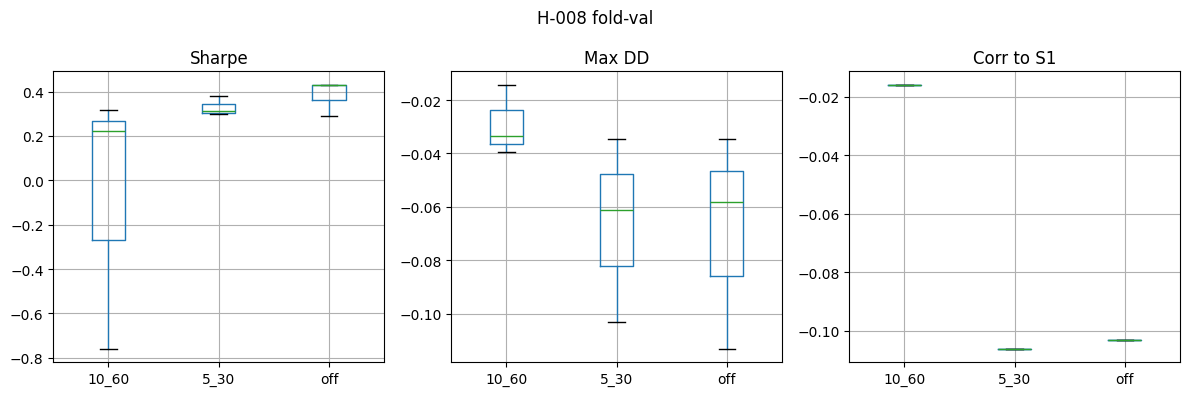

median-Sharpe hint (commentary only): off


,arm,median_val_sharpe,full_is_sharpe,max_drawdown,corr_to_s1,n_folds,median_psr,median_dsr_local,median_dsr_stack,full_is_psr,full_is_dsr_local,full_is_dsr_stack
0,10_60,0.222380,0.075797,-0.033338,-0.015883,3,0.999484,0.998921,0.997147,0.999999,0.999982,0.99935
1,5_30,0.310758,0.480206,-0.061080,-0.106188,3,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000
2,off,0.431385,0.610792,-0.058181,-0.103199,3,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [6]:
plot_fold_boxplots(fold_df, title="H-008 fold-val")
plt.show()
print("median-Sharpe hint (commentary only):", median_sharpe_hint(fold_df))
display(arm_selection_table(fold_df, full_is_df))


## 6. Type `HL_GATE_STAR` then save


In [7]:
HL_GATE_STAR = "off"  # TODO set after review — do not use argmax / median Sharpe
require_star("HL_GATE_STAR", HL_GATE_STAR)
stack["HL_GATE_STAR"] = HL_GATE_STAR
save_star_stack(STAR_PATH, stack)
print("wrote", STAR_PATH)


wrote C:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\04_backtest\s2_coint\artifacts\s2_star_stack.json


## 7. Sealed OOS once


In [ ]:
require_star("HL_GATE_STAR", HL_GATE_STAR)
oos_cfg = config_from_stack(load_star_stack(STAR_PATH))
n_loc = n_trials_local(configs)
n_stk = n_trials_stack(HYP_ID, configs)
oos = run_s2_backtest(
    oos_panel, oos_cfg, s1_weekly=s1_weekly,
    n_trials_local=n_loc,
    n_trials_stack=n_stk,
)

print(oos.metrics)
write_tearsheet_pdf(
    tearsheet_path("H-008", str(HL_GATE_STAR)), oos.returns, title="H-008 sealed OOS",
    n_trials_local=n_loc,
    n_trials_stack=n_stk,
)

print("tearsheet", tearsheet_path("H-008", str(HL_GATE_STAR)))


## 8. Notes for next hyp


H-009 overlapping legs (`allow` vs `never_allow`) is next.
